In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
test = pd.read_csv("fd1_train.csv")
train = pd.read_csv("fd4_train.csv")


In [3]:
train.head()

,id,cycle,s1,s2,s3,s4,s5,s6,s7,s8,...,s16,s17,s18,s19,s20,s21,s22,s23,s24,rul
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670,320.0
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552,319.0
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213,318.0
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176,317.0
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754,316.0


In [4]:
train.describe()

,id,cycle,s1,s2,s3,s4,s5,s6,s7,s8,...,s16,s17,s18,s19,s20,s21,s22,s23,s24,rul
count,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,...,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000
mean,124.325181,134.311417,23.999823,0.571347,94.031576,472.882435,579.420056,1417.896600,1201.915359,8.031626,...,2334.427590,8067.811812,9.285604,0.023252,347.760029,2228.613283,97.751396,20.864333,12.518995,133.311417
std,71.995350,89.783389,14.780722,0.310703,14.251954,26.436832,37.342647,106.167598,119.327591,3.622872,...,128.197859,85.670543,0.750374,0.004685,27.808283,145.472491,5.369424,9.936396,5.962697,89.783389
min,1.000000,1.000000,0.000000,0.000000,60.000000,445.000000,535.480000,1242.670000,1024.420000,3.910000,...,2027.570000,7845.780000,8.175700,0.020000,302.000000,1915.000000,84.930000,10.160000,6.084300,0.000000
25%,60.000000,62.000000,10.004600,0.250700,100.000000,445.000000,549.330000,1350.550000,1119.490000,3.910000,...,2387.910000,8062.630000,8.648000,0.020000,330.000000,2212.000000,100.000000,10.940000,6.566100,61.000000
50%,126.000000,123.000000,25.001400,0.700000,100.000000,462.540000,555.740000,1367.680000,1136.920000,7.050000,...,2388.060000,8083.810000,9.255600,0.020000,334.000000,2223.000000,100.000000,14.930000,8.960100,122.000000
75%,185.000000,191.000000,41.998100,0.840000,100.000000,491.190000,607.070000,1497.420000,1302.620000,10.520000,...,2388.170000,8128.350000,9.365800,0.030000,368.000000,2324.000000,100.000000,28.560000,17.135500,190.000000
max,249.000000,543.000000,42.008000,0.842000,100.000000,518.670000,644.420000,1613.000000,1440.770000,14.620000,...,2390.490000,8261.650000,11.066300,0.030000,399.000000,2388.000000,100.000000,39.890000,23.885200,542.000000


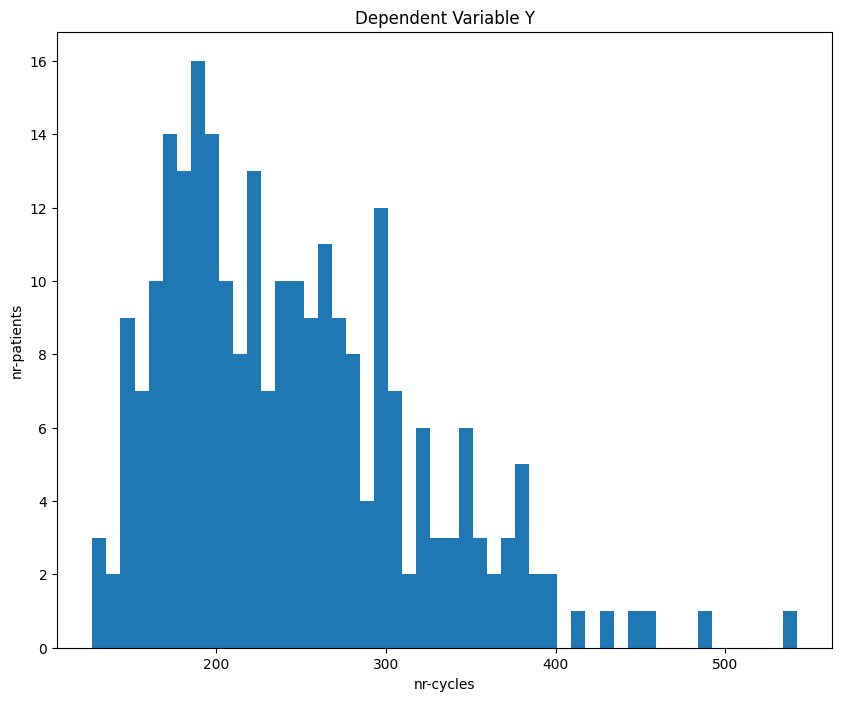

In [20]:
# look at the dependent variable distribution

plt.figure(figsize=(10, 8))
plt.hist(train.groupby(["id"]).max("rul")["rul"], bins=50)
plt.ylabel("nr-patients")
plt.xlabel("nr-cycles")
plt.title("Dependent Variable Y")
plt.show()
    


In [21]:
train.head()

,id,cycle,s1,s2,s3,s4,s5,s6,s7,s8,...,s16,s17,s18,s19,s20,s21,s22,s23,s24,rul
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670,320.0
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552,319.0
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213,318.0
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176,317.0
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754,316.0


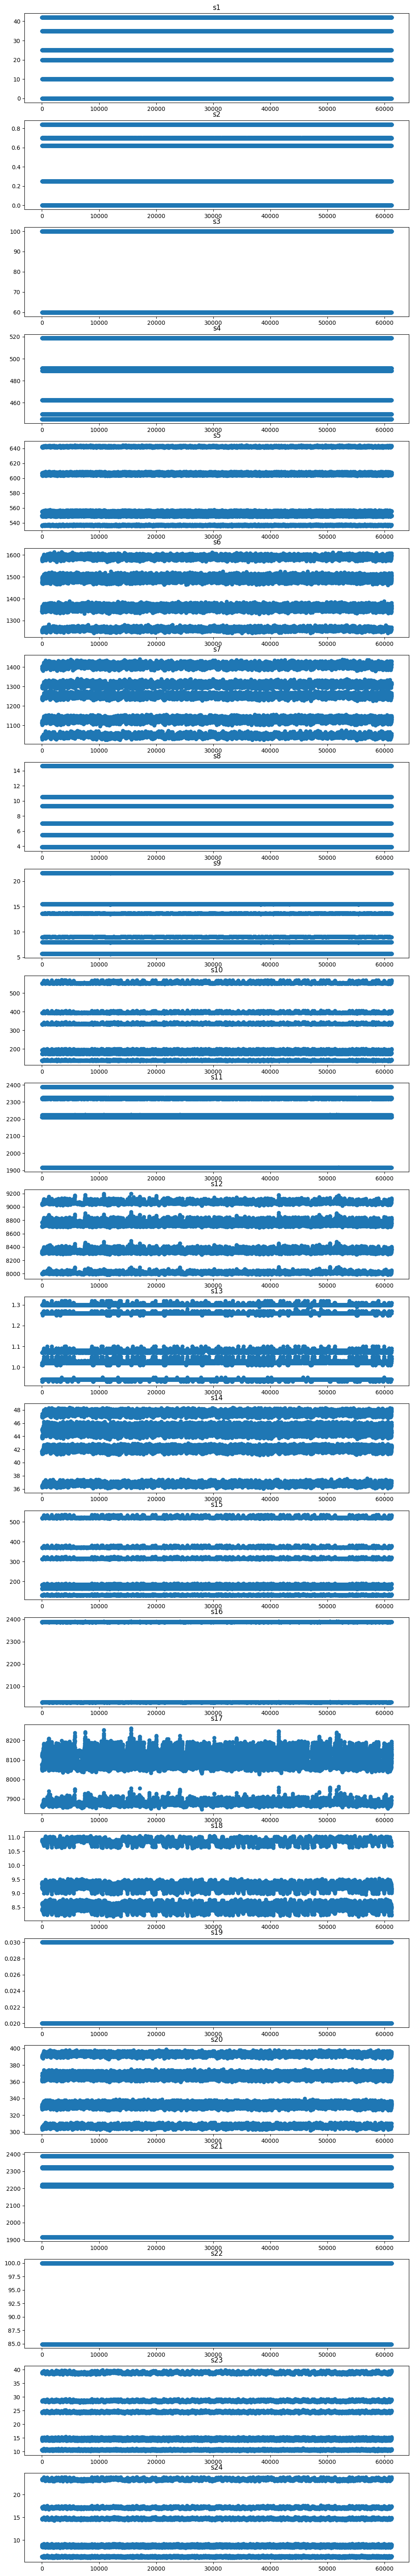

In [34]:

fig, axs  = plt.subplots(24, 1, figsize=(12, 80))
ax = np.ravel(axs)
for ind, feature in enumerate(train.iloc[:, 2:-1].columns):
    ax[ind].scatter(train.index, train[feature])
    ax[ind].set_title(feature)
plt.show()

In [26]:
X[:, 2:-1].shape

(61249, 24)

In [28]:
X[0, :]

array([1.00000e+00, 1.00000e+00, 4.20049e+01, 8.40000e-01, 1.00000e+02,
       4.45000e+02, 5.49680e+02, 1.34343e+03, 1.11293e+03, 3.91000e+00,
       5.70000e+00, 1.37360e+02, 2.21186e+03, 8.31132e+03, 1.01000e+00,
       4.16900e+01, 1.29780e+02, 2.38799e+03, 8.07483e+03, 9.33350e+00,
       2.00000e-02, 3.30000e+02, 2.21200e+03, 1.00000e+02, 1.06200e+01,
       6.36700e+00, 3.20000e+02])